# Group-level satistical analysis of brain electrical properties - Experiment n°5
This notebook presents the fourth experiment of the group level statistical analysis of brain electrical properties ($\sigma$ and $\epsilon_r$). In this experiment, we investigate the effect of HIE

Part of nano-eptk package by Arnaud Boutillon (arnaud.boutillon@kcl.ac.uk).

## Python environment setting

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf

from scipy.stats import ttest_ind

base_dir = os.path.abspath(os.path.join(os.path.pardir, os.path.pardir))
data_dir = os.path.join(base_dir, "data")
results_dir = os.path.join(base_dir, "results")
src_dir = os.path.join(base_dir, "src")
sys.path.append(os.path.join(src_dir))

from utils.stats import *
from utils.plots import *

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore")

## 1. Filter data and outlier removal

In [2]:
def filter_outlier_df(df, cols):
    mus = []
    stds = []
    for col in cols:
        mus += [df[col].mean()]
        stds += [df[col].std()]
    # Merge mask
    mask = np.ones(len(df), dtype=bool)
    for i, col in enumerate(cols):
        mask &= (df[col] < mus[i] + 2.5*stds[i]) & (df[col] > mus[i] - 2.5*stds[i])
    return df[mask]


def filter_HIE_and_dHCP_df(dhcp_tse_df_path, dhcp_cov_df_path, hie_df_path, df_path):
    # Load
    dhcp_tse_df = pd.read_csv(dhcp_tse_df_path)
    dhcp_cov_df = pd.read_csv(dhcp_cov_df_path)
    hie_df = pd.read_csv(hie_df_path)

    # Merge dHCP
    keys = ["subject_id", "PMA"]
    dhcp_df = pd.merge(dhcp_cov_df, dhcp_tse_df, on=keys, how="inner")

    # dHCP filter 
    dhcp_df = dhcp_df.dropna(subset=["RVV", "brain_MD", "rad_score"])
    dhcp_df = dhcp_df[dhcp_df["PTB"] < 0] # ie GA > 37
    dhcp_df = dhcp_df[dhcp_df["rad_score"] > 1.0] # i.e. exlcude possible incidental findings
    dhcp_df = dhcp_df.drop_duplicates(subset="subject_id", keep=False)

    # HIE filter
    hie_df = hie_df.dropna(subset=["RVV", "brain_MD"])
    hie_df = hie_df[hie_df["PTB"] < 0]
    hie_df = hie_df.drop_duplicates(subset="subject_id", keep=False)

    # PNA = PMA - GA = PMA - (37 - PTB)
    dhcp_df["PNA"] = dhcp_df["PMA"] - (37 - dhcp_df["PTB"])
    hie_df["PNA"] = hie_df["PMA"] - (37 - hie_df["PTB"])

    # Outlier removal
    cols = ["PMA", "PNA", "TSE_brain_SIG", "RVV", "brain_MD"]
    dhcp_df = filter_outlier_df(dhcp_df, cols)
    hie_df = filter_outlier_df(hie_df, cols)
    
    # Merge HIE and dHCP
    dhcp_df["Type"] = "Control"
    hie_df["Type"] = "HIE"
    df = pd.concat([hie_df, dhcp_df], ignore_index=True)

    #
    cols = ["subject_id", "Type", "PMA", "PNA", "RVV", "brain_MD", "TSE_brain_SIG"]
    df = df[cols]
    
    df.to_csv(df_path, index=False)

In [3]:
# Set file path
csv_dir = os.path.join(data_dir, "cohorts_csv")
dhcp_tse_df_path = os.path.join(csv_dir, "dHCP_TSE.csv")
dhcp_cov_df_path = os.path.join(csv_dir, "dHCP_COV.csv")
hie_df_path = os.path.join(csv_dir, "HIE.csv")
df_path = os.path.join(csv_dir, "HIE_and_dHCP_filtered.csv")

# Filter and load filtered dataframe
filter_HIE_and_dHCP_df(dhcp_tse_df_path, dhcp_cov_df_path, hie_df_path, df_path)
df = pd.read_csv(df_path)

# Display cohort size
print(f"Total subjects = {len(df.index)}")
print(f"dHCP subjects = {len(df[df["Type"] == "Control"].index)}")
print(f"HIE subjects = {len(df[df["Type"] == "HIE"].index)}")

Total subjects = 459
dHCP subjects = 431
HIE subjects = 28


## 2. Correlation matrix

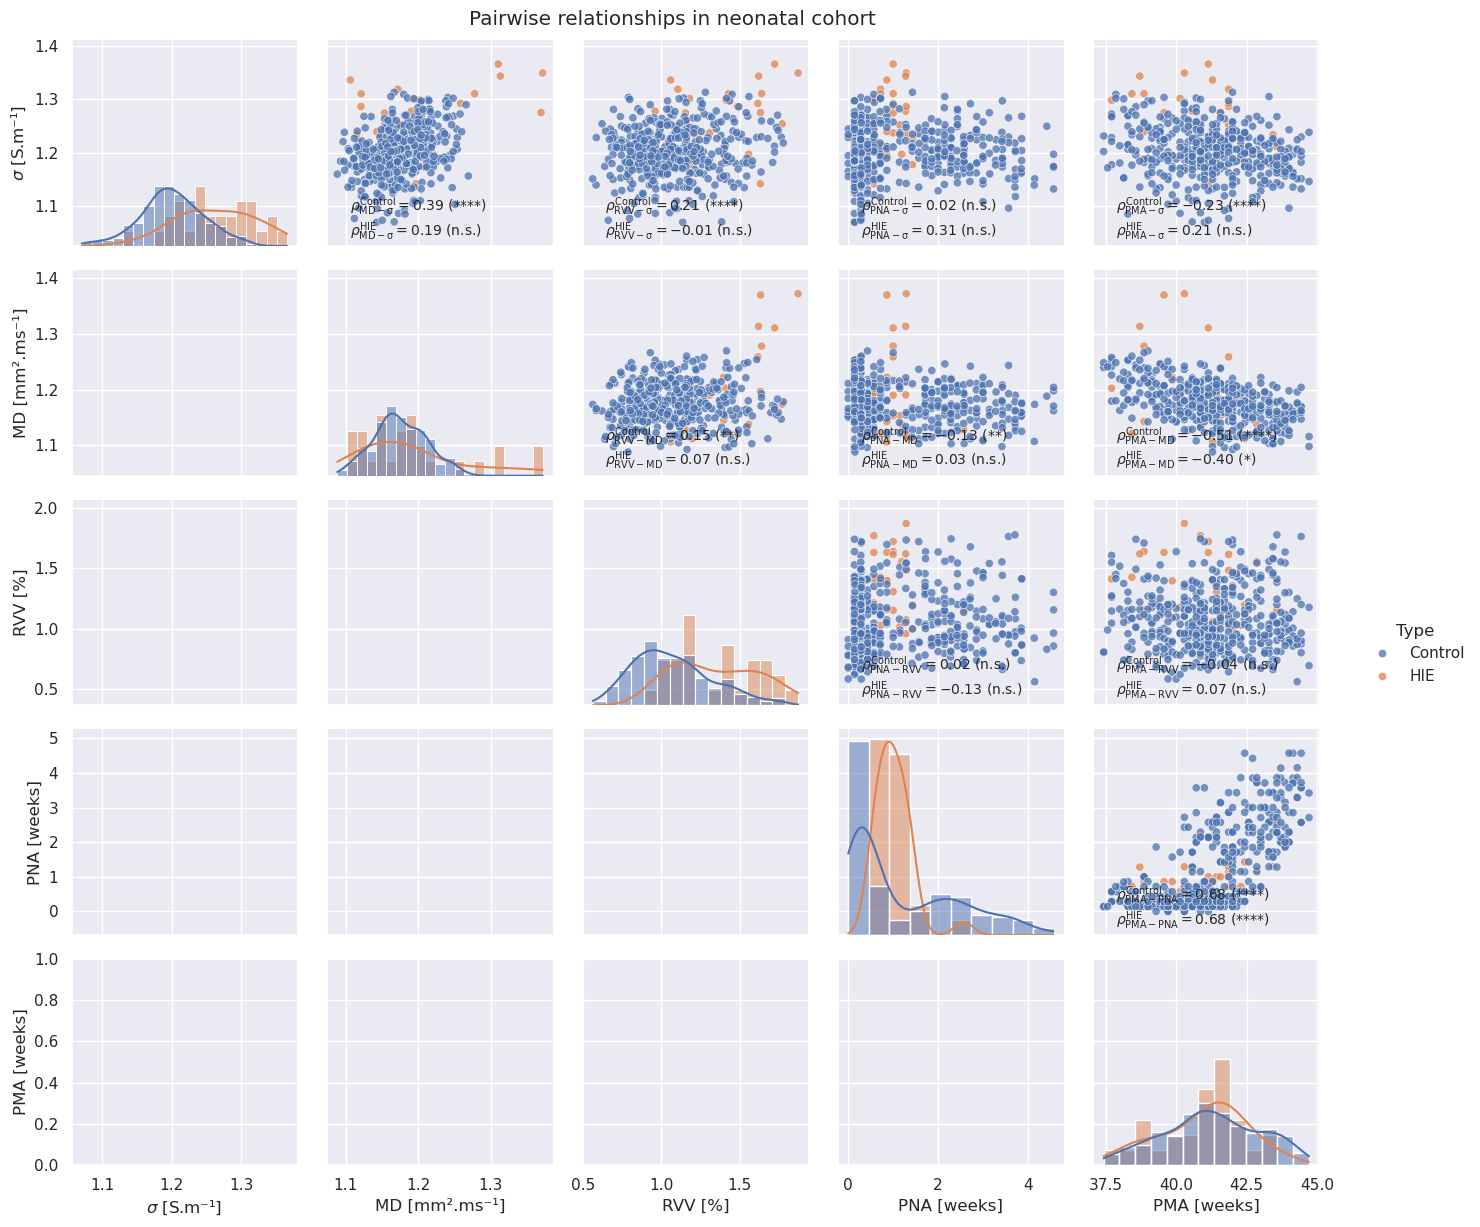

In [4]:
# Set file path
plot_dir = os.path.join(results_dir, "plots", "experiments")
plot_path = os.path.join(plot_dir, "experiment5A.png")

# Load dataframe
df = pd.read_csv(df_path)

#
type_col = "Type"
type_labels = ["Control", "HIE"]
type_idx = []
off = 0
for type_label in type_labels:
    n = len(df[df[type_col] == type_label].index)
    type_idx += [np.arange(off,n+off)]
    off += n

#
df = df[["TSE_brain_SIG", "brain_MD", "RVV", "PNA", "PMA", "Type"]]
df = df.rename(columns={
    "TSE_brain_SIG": r"$\sigma$ [S.m⁻¹]",
    "brain_MD": "MD [mm².ms⁻¹]",
    "RVV": "RVV [%]",
    "PNA": "PNA [weeks]",
    "PMA": "PMA [weeks]",
})

# Initialize plot
g = sns.PairGrid(df, hue=type_col, hue_order=type_labels)
g.fig.suptitle("Pairwise relationships in neonatal cohort")

# Plot data
g.map_diag(sns.histplot, kde=True, stat="proportion", common_norm=False)
g.map_upper(sns.scatterplot, alpha=0.75)
g.map_upper(annotate_cat_pairplot, cats=type_labels, cats_idx=type_idx)

# Legend
g.add_legend()
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 0.5))

# Adjust layout
g.fig.tight_layout()

# Save plot
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

## 3. Effect of HIE on brain conductivity and MD

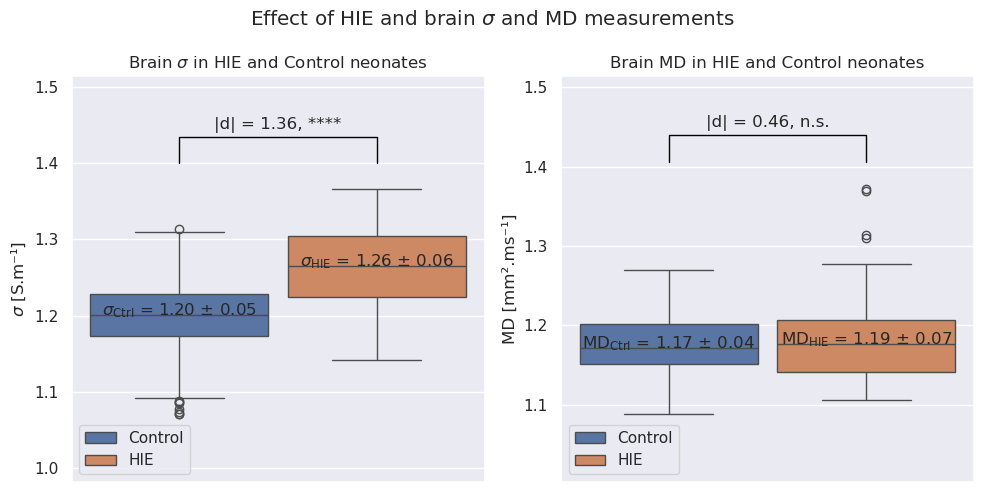

In [5]:
# Set file path
plot_path = os.path.join(plot_dir, "experiment5B.png")

# Load dataframe
df = pd.read_csv(df_path)

#
sig_col = "TSE_brain_SIG"
md_col = "brain_MD"
type_col = "Type"

#
metrics = [sig_col, md_col]
type_labels = ["Control", "HIE"]
comparisons = [('Control', 'HIE')]
labels = [r"$\sigma$ [S.m⁻¹]", "MD [mm².ms⁻¹]"]
symbols = [r"$\sigma$", "MD"]

#
ylims = [calculate_plot_lim(df[metric], coeff_min=0.3, coeff_max=0.5) for metric in metrics]

#
fig, axes = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle(r"Effect of HIE and brain $\sigma$ and MD measurements")

#
for i, metric in enumerate(metrics):
    #
    sns.boxplot(data=df, ax=axes[i], hue=type_col, hue_order=type_labels, y=metric, gap=.1)
    axes[i].set_xlabel(None)
    axes[i].set_ylabel(labels[i])
    axes[i].set_title(f"Brain {symbols[i]} in HIE and Control neonates")
    axes[i].set_ylim(ylims[i])
    axes[i].legend(loc="lower left")
    
# Statistical annotations
m = len(comparisons)
for i, metric in enumerate(metrics):
    for j, (g1, g2) in enumerate(comparisons):
        # Welch t-test
        y1 = df[df[type_col] == g1][metric]
        y2 = df[df[type_col] == g2][metric]
        stat, p = ttest_ind(y1, y2, equal_var=False)
        stars = convert_pvalue_to_asterisks(p)

        # 
        eff = np.abs(pg.compute_effsize(y1, y2, paired=False, eftype='cohen'))

        # Bar annotation
        x1 = -0.2
        x2 = 0.2
        y_max = df[metric].max() + (j+1) * 0.025 * df[metric].max()
        offset = 0.025 * df[metric].max()
        axes[i].plot([x1, x1, x2, x2], [y_max, y_max + offset, y_max + offset, y_max], color='black', lw=1)
        axes[i].text(j, y_max + offset + 0.01, f"|d| = {eff:.2f}, {stars}", ha='center')

# Annotation of means ± std
for i, metric in enumerate(metrics):
    for j, cat in enumerate(type_labels):
        # Extract statistics
        group = df[df[type_col] == cat][metric]
        y_mean = group.mean()
        y_std = group.std()
        y_med = group.median()

        # Annotate
        base = r"\sigma" if i == 0 else "\mathregular{MD}"
        if cat == "Control":
            cat = "Ctrl"
        label = f"${base}_{{\mathregular{{{cat}}}}}$"
        xc = -0.2 if j == 0 else 0.2
        axes[i].text(xc, y_med, f"{label} = {y_mean:.2f} ± {y_std:.2f}", ha='center')

# Adjust layout
fig.tight_layout()

# Save plot
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

## 4. Effect of HIE on brain conductivity and MD controlling for PMA

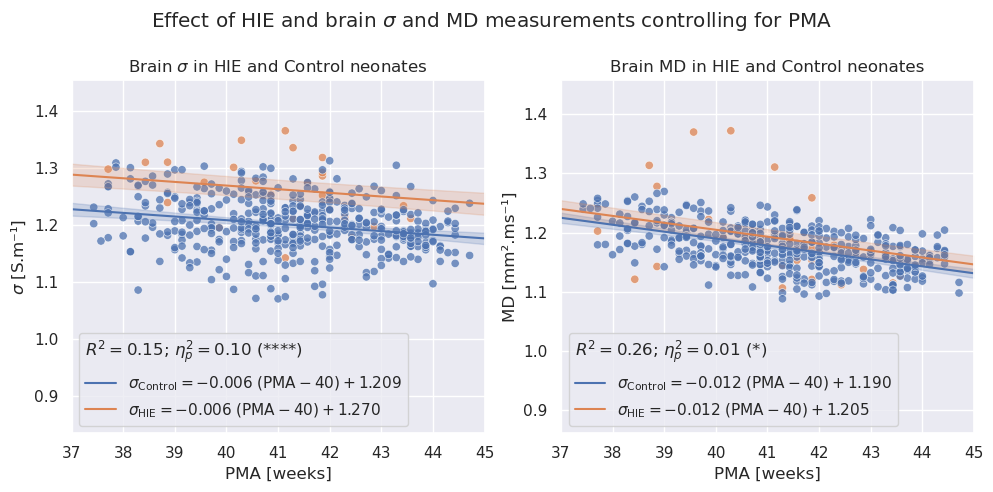

In [6]:
# Set file path
plot_path = os.path.join(plot_dir, "experiment5C.png")
summary_path = os.path.join(results_dir, "statsmodels", "experiment5C.txt")

# Load dataframe
df = pd.read_csv(df_path)

# Center data
pma_col = "PMA"
pmac_col = "PMA_c"
pma_center = 40
df[pmac_col] = df[pma_col] - pma_center

#
sig_col = "TSE_brain_SIG"
md_col = "brain_MD"
type_col = "Type"

#
metrics = [sig_col, md_col]
type_labels = ['Control', 'HIE']
labels = [r"$\sigma$ [S.m⁻¹]", "MD [mm².ms⁻¹]"]
symbols = [r"$\sigma$", "MD"]

#
palette = sns.color_palette()

#
xlim = [37, 45]
ylims = [calculate_plot_lim(df[metric], coeff_min=0.8, coeff_max=0.3) for metric in metrics]

#
fig, axes = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle(r"Effect of HIE and brain $\sigma$ and MD measurements controlling for PMA")

#
for i, metric in enumerate(metrics):
    #
    formula = f"{metric} ~ {pmac_col} + C({type_col}) - 1"
    lm = smf.ols(formula, df).fit()
    formula = f"{metric} ~ {pmac_col} + C({type_col})"
    lm_inter = smf.ols(formula, df).fit()
    formula = f"{metric} ~ {pmac_col} + C({type_col})*{pmac_col} + C({type_col})"
    lm_inter_pma = smf.ols(formula, df).fit()

    #
    acv = pg.ancova(data=df, dv=metric, between=type_col, covar=pmac_col, effsize="np2")

    #
    sns.scatterplot(data=df, ax=axes[i], x=pma_col, y=metric, hue=type_col, hue_order=type_labels, alpha=0.75, legend=False)
    axes[i].set_xlabel("PMA [weeks]")
    axes[i].set_ylabel(labels[i])
    axes[i].set_title(f"Brain {symbols[i]} in HIE and Control neonates")
    axes[i].set_xlim(xlim)
    axes[i].set_ylim(ylims[i])
    
    for j, cat in enumerate(type_labels):
        n = 100
        X = np.linspace(xlim[0], xlim[1], num=n)
        pred = lm.get_prediction({pmac_col: X-pma_center, type_col: n*[cat]})
        pred_summary = pred.summary_frame(alpha=0.05)  # 95% confidence intervals
    
        slope = lm.params[pmac_col]
        intercept = lm.params[f"C({type_col})[{cat}]"]
    
        slope_txt = f"{slope:.3f}"
        coeff_txt = rf"\; (\mathregular{{PMA}} - {pma_center})"
        intercept_txt = f"+ {intercept:.3f}" if intercept >= 0 else f"- {abs(intercept):.3f}"
        var_symbol = rf"\sigma_{{\mathregular{{{cat}}}}}"
        label = f"${var_symbol} = {slope_txt}{coeff_txt} {intercept_txt}$"
    
        axes[i].plot(X, intercept + slope * (X-pma_center), color=palette[j], label=label)
        axes[i].fill_between(X, pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'], color=palette[j], alpha=0.2) 

    #
    r2 = lm.rsquared
    np2 = acv["np2"].values
    pval = acv["p-unc"].values
    stars = convert_pvalue_to_asterisks(pval[0])
    leg = axes[i].legend(loc="lower left", title=rf"$R^2 = {r2:.2f}$; $\eta_p^2 = {np2[0]:.2f}$ ({stars})")
    leg._legend_box.align = "left"

    # Write summary
    write_mode = "a" if i else "w"
    with open(summary_path, write_mode) as fh:
        fh.write(lm.summary().as_text())
        fh.write("\n\n")
        fh.write(lm_inter.summary().as_text())
        fh.write("\n\n")
        fh.write(lm_inter_pma.summary().as_text())
        fh.write("\n\nANCOVA\n")
        fh.write(acv.to_string(index=False))
        fh.write("\n\n\n\n")

# Adjust layout
fig.tight_layout()

# Save plot
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

In [7]:
# Model summary
f = open(summary_path, 'r')
file_contents = f.read()
print(file_contents)
f.close()

                            OLS Regression Results                            
Dep. Variable:          TSE_brain_SIG   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     39.04
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           2.24e-16
Time:                        17:16:22   Log-Likelihood:                 774.20
No. Observations:                 459   AIC:                            -1542.
Df Residuals:                     456   BIC:                            -1530.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
C(Type)[Control]     1.2087      0.003  